In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

df=pd.read_csv("../data/advertising.csv")

In [2]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
tv_data=np.array(df["TV"])
radio_data=np.array(df["Radio"])
newspaper_data=np.array(df["Newspaper"])
sales_data=np.array(df["Sales"])

In [4]:
def predict(x1, x2, x3, w1, w2, w3, b):
    return w1*x1 + w2*x2 + w3*x3 + b

# Compute Gradient
def compute_gradient(y_hat, y, x1, x2, x3):
    dw1=2*x1*(y_hat-y)
    dw2=2*x2*(y_hat-y)
    dw3=2*x3*(y_hat-y)
    db=2*(y_hat-y)
    return (dw1, dw2, dw3, db)

# Update Parameter
def update_paramters(w1, w2, w3, b, lr, combined_dw1, combined_dw2, combined_dw3, combined_db):
    w_new1=w1-lr*combined_dw1
    w_new2=w2-lr*combined_dw2
    w_new3=w3-lr*combined_dw3
    b_new=b-lr*combined_db
    return (w_new1, w_new2, w_new3, b_new)

# Loss Function
def compute_loss(y_hat, y):
    return (y_hat-y)**2

In [17]:
def mini_batch_training(m=100):
    # Initialization
    b = 0
    w1 = random.gauss(mu=0.0, sigma=0.01)
    w2 = random.gauss(mu=0.0, sigma=0.01)
    w3 = random.gauss(mu=0.0, sigma=0.01)
    lr = 1e-5
    # How long
    epoch_max=50
    N=len(df)
    losses=[]
    # Implementation
    for _ in range(epoch_max):
        for i in range(0, N, m):
            dw1, dw2, dw3, db = [], [], [], []
            loss_total=0
            for j in range(m):
                x1=tv_data[i+j]
                x2=radio_data[i+j]
                x3=newspaper_data[i+j]
                y=sales_data[i+j]

                y_hat=predict(x1, x2, x3, w1, w2, w3, b)
                loss_total+=compute_loss(y_hat, y)
                
                grad_w1, grad_w2, grad_w3, grad_b = compute_gradient(y_hat, y, x1, x2, x3)
                dw1.append(grad_w1)
                dw2.append(grad_w2)
                dw3.append(grad_w3)
                db.append(grad_b)

            losses.append(loss_total/m)  
            combined_dw1=sum(dw1)/m
            combined_dw2=sum(dw2)/m
            combined_dw3=sum(dw3)/m
            combined_db=sum(db)/m
            w1, w2, w3, b = update_paramters(w1, w2, w3, b, lr, combined_dw1, combined_dw2, combined_dw3, combined_db)

    plt.plot(losses[:5], marker='o')
    plt.show()


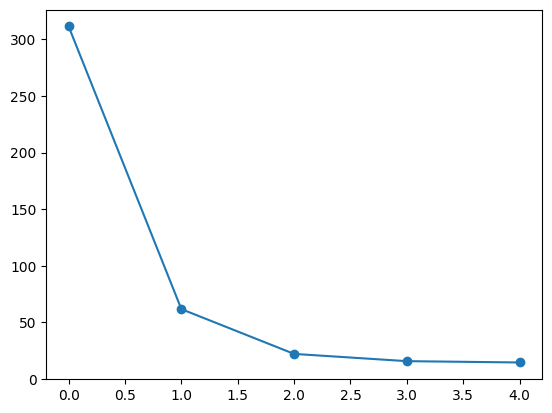

In [18]:
mini_batch_training(200)